# Pipeline vs Baseline Experiment

In [21]:
import sys
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

BASELINE_DIR = REPO_ROOT / "baseline"
if str(BASELINE_DIR) not in sys.path:
    sys.path.insert(0, str(BASELINE_DIR))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_PATH = REPO_ROOT / "database" / "training_data.json"
EXPERIMENT_DIR = REPO_ROOT / "experiments"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"CUDA available: {torch.cuda.is_available()}")

Repo root: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline
Data path: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/database/training_data.json
CUDA available: True


In [22]:
import logging
from datetime import datetime

from logger import configure_logging

TRACE_LOG_PATH = EXPERIMENT_DIR / f"experimentation_pipeline_vs_baseline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
configure_logging(
    level="INFO",
    log_file=str(TRACE_LOG_PATH),
    enable_console=True,
    enable_file=True,
)

exp_logger = logging.getLogger("experimentation_pipeline_vs_baseline")
exp_logger.info("Trace logging initialized")
print(f"Trace log file: {TRACE_LOG_PATH}")

2026-03-24 13:56:10,528 - experimentation_pipeline_vs_baseline - INFO - Trace logging initialized
Trace log file: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/experiments/experimentation_pipeline_vs_baseline_20260324_135610.log


In [23]:
TARGET = {
    "dbaasp_id": "DBAASPS_373",
    "sequence": "KLFKRWKHLFR",
    "length": 11,
    "smiles": "CC(C)C[C@H](NC(=O)[C@H](Cc1cnc[nH]1)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1c[nH]c2ccccc12)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](N)CCCCN)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCCN=C(N)N)C(=O)O",
    "ph": None,
    "molecular_weight": 1558.9480000000003,
    "logp": -0.992100000000006,
    "net_charge": 5.0,
    "isoelectric_point": 12.18,
    "hydrophobicity": 1.05,
    "cathionicity": 6,
    "target_groups": ["Gram+"],
    "complexity": "Monomer"
}

SHARED_MAX_LEN = 14
SHARED_BATCH_SIZE = 32
SHARED_EPOCHS = 100
SHARED_LATENT_DIM = 32

# Tuned pipeline hyperparameters (from pipeline_experimentations reference setup).
PIPELINE_LATENT_DIM = 64
PIPELINE_HIDDEN_DIM = 512
PIPELINE_EPOCHS = 120
PIPELINE_BATCH_SIZE = 64
PIPELINE_LR = 0.05
PIPELINE_KL_ANNEAL_EPOCHS = 40

NB_ITERATIONS = 50
NB_PEPTIDES = 300
TOP_K = 10
BASELINE_NUM_SAMPLES = 10

print(TARGET)
print(
    f"Pipeline tuned config -> latent={PIPELINE_LATENT_DIM}, hidden={PIPELINE_HIDDEN_DIM}, "
    f"epochs={PIPELINE_EPOCHS}, batch={PIPELINE_BATCH_SIZE}, lr={PIPELINE_LR}, kl_anneal={PIPELINE_KL_ANNEAL_EPOCHS}"
)

{'dbaasp_id': 'DBAASPS_373', 'sequence': 'KLFKRWKHLFR', 'length': 11, 'smiles': 'CC(C)C[C@H](NC(=O)[C@H](Cc1cnc[nH]1)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1c[nH]c2ccccc12)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](N)CCCCN)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCCN=C(N)N)C(=O)O', 'ph': None, 'molecular_weight': 1558.9480000000003, 'logp': -0.992100000000006, 'net_charge': 5.0, 'isoelectric_point': 12.18, 'hydrophobicity': 1.05, 'cathionicity': 6, 'target_groups': ['Gram+'], 'complexity': 'Monomer'}
Pipeline tuned config -> latent=64, hidden=512, epochs=120, batch=64, lr=0.05, kl_anneal=40


In [24]:
from training import train_model
from inference import generate_peptides

baseline_model_path = EXPERIMENT_DIR / "baseline_cvae_model.pth"
baseline_scaler_path = EXPERIMENT_DIR / "baseline_scaler.pkl"

baseline_model, _ = train_model(
    dataset_file=str(DATA_PATH),
    scaler_path=str(baseline_scaler_path),
    batch_size=SHARED_BATCH_SIZE,
    max_len=SHARED_MAX_LEN,
    epochs=SHARED_EPOCHS,
    latent_dim=SHARED_LATENT_DIM,
    model_path=str(baseline_model_path),
)

with open(baseline_scaler_path, "rb") as f:
    baseline_scaler = pickle.load(f)

baseline_target = [
    TARGET["length"],
    7.0 if TARGET["ph"] is None else float(TARGET["ph"]),
    TARGET["molecular_weight"],
    TARGET["logp"],
    TARGET["net_charge"],
    TARGET["isoelectric_point"],
    TARGET["hydrophobicity"],
    TARGET["cathionicity"],
]

baseline_sequences = generate_peptides(
    model=baseline_model,
    scaler=baseline_scaler,
    num_samples=BASELINE_NUM_SAMPLES,
    properties=baseline_target,
    temperature=0.9,
    top_k=5,
)

Using device: cuda
Scaler saved to /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/experiments/baseline_scaler.pkl
Epoch [1/100] | Beta: 0.00 | Train Loss: 21.4799 | Train Recon: 21.4799 | Train KL: 66.7116 | Val Loss: 18.3806 | Val Recon: 18.3806 | Val KL: 108.8033
Epoch [5/100] | Beta: 0.08 | Train Loss: 13.9652 | Train Recon: 12.3938 | Train KL: 19.6430 | Val Loss: 13.4713 | Val Recon: 11.9304 | Val KL: 19.2605
Epoch [10/100] | Beta: 0.18 | Train Loss: 11.5829 | Train Recon: 8.9925 | Train KL: 14.3912 | Val Loss: 11.8423 | Val Recon: 9.3397 | Val KL: 13.9030
Epoch [15/100] | Beta: 0.28 | Train Loss: 10.7538 | Train Recon: 7.5165 | Train KL: 11.5619 | Val Loss: 11.6593 | Val Recon: 8.5647 | Val KL: 11.0521
Epoch [20/100] | Beta: 0.38 | Train Loss: 10.7060 | Train Recon: 7.1009 | Train KL: 9.4871 | Val Loss: 11.9754 | Val Recon: 8.4172 | Val KL: 9.3638
Epoch [25/100] | Beta: 0.48 | Train Loss: 10.7938 | Train Recon: 6.9396 | Train KL: 8.0294 | Val Loss: 12.0935 | Val Recon

In [25]:
from peptide_pipeline.dataloader.dataloader_json import DataLoader as JSONDataLoader
from peptide_pipeline.generator.cvae_generator_agent.cvae_generator import CVAEGenerator

AA = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_IDX = {aa: i for i, aa in enumerate(AA)}
PAD_IDX = 20
VOCAB_SIZE = 21


def encode_one_hot_with_pad(sequences, max_len):
    x = torch.zeros(len(sequences), max_len * VOCAB_SIZE, dtype=torch.float32)
    for i, seq in enumerate(sequences):
        for pos in range(max_len):
            x[i, pos * VOCAB_SIZE + PAD_IDX] = 1.0
        for pos, aa in enumerate(seq[:max_len]):
            if aa in AA_TO_IDX:
                x[i, pos * VOCAB_SIZE + PAD_IDX] = 0.0
                x[i, pos * VOCAB_SIZE + AA_TO_IDX[aa]] = 1.0
    return x


def build_condition_tensor(dataframe, model):
    cond = torch.zeros(len(dataframe), model.condition_dim, dtype=torch.float32)
    cond[:, 0] = torch.tensor(dataframe["length"].values, dtype=torch.float32)
    cond[:, 1] = torch.tensor(dataframe["molecular_weight"].values, dtype=torch.float32)
    cond[:, 2] = torch.tensor(dataframe["net_charge"].values, dtype=torch.float32)
    cond[:, 3] = torch.tensor(dataframe["isoelectric_point"].values, dtype=torch.float32)
    cond[:, 4] = torch.tensor(dataframe["hydrophobicity"].values, dtype=torch.float32)
    cond[:, 5] = torch.tensor(dataframe["cathionicity"].values, dtype=torch.float32)
    cond[:, 6] = 0.5
    cond[:, 7] = torch.tensor(dataframe["logp"].values, dtype=torch.float32)
    cond[:, 8] = 0.0
    cond[:, 9] = 5.0
    cond[:, 10] = 5.0
    cond[:, 11] = 100.0
    return cond


loader = JSONDataLoader()
loader.load_data(
    source=str(DATA_PATH),
    columns=[
        "sequence",
        "length",
        "ph",
        "molecular_weight",
        "logp",
        "net_charge",
        "isoelectric_point",
        "hydrophobicity",
        "cathionicity",
    ],
    fillna_defaults={
        "length": 10,
        "ph": 7.0,
        "molecular_weight": 1500.0,
        "logp": 0.0,
        "net_charge": 0.0,
        "isoelectric_point": 7.0,
        "hydrophobicity": 0.0,
        "cathionicity": 0.0,
    },
    normalize_sequence=True,
    sequence_column="sequence",
    keep_standard_amino_acids_only=True,
)

pipeline_df = loader.get_data().copy()

pipeline_cvae = CVAEGenerator(
    max_len=SHARED_MAX_LEN,
    latent_dim=PIPELINE_LATENT_DIM,
    hidden_dim=PIPELINE_HIDDEN_DIM,
    condition_dim=32,
)

pipeline_model_path = EXPERIMENT_DIR / (
    f"pipeline_cvae_model_lat{PIPELINE_LATENT_DIM}_hid{PIPELINE_HIDDEN_DIM}_ep{PIPELINE_EPOCHS}_bs{PIPELINE_BATCH_SIZE}.pth"
)

x = encode_one_hot_with_pad(pipeline_df["sequence"].tolist(), max_len=SHARED_MAX_LEN)
conditions = build_condition_tensor(pipeline_df, pipeline_cvae)
lengths = torch.tensor(pipeline_df["length"].astype(int).values, dtype=torch.long)

x = x.to(pipeline_cvae.device)
conditions = conditions.to(pipeline_cvae.device)
lengths = lengths.to(pipeline_cvae.device)

if pipeline_model_path.exists():
    pipeline_cvae.load_model(str(pipeline_model_path))
else:
    pipeline_cvae.train_model(
        data=x,
        conditions=conditions,
        lengths=lengths,
        epochs=PIPELINE_EPOCHS,
        batch_size=PIPELINE_BATCH_SIZE,
        lr=PIPELINE_LR,
        kl_anneal_epochs=PIPELINE_KL_ANNEAL_EPOCHS,
    )
    pipeline_cvae.save_model(str(pipeline_model_path))

print(f"Using pipeline model path: {pipeline_model_path.name}")

2026-03-24 13:56:52,366 - peptide_pipeline.dataloader - INFO - DataLoader initialized.
2026-03-24 13:56:52,396 - peptide_pipeline.dataloader - INFO - Data loaded successfully from /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/database/training_data.json. Total records: 4410
2026-03-24 13:56:52,397 - peptide_pipeline.dataloader - INFO - Data retrieval successful.
Using pipeline model path: pipeline_cvae_model_lat64_hid512_ep120_bs64.pth


In [26]:
from peptide_pipeline.chemist.chemist_agent.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.chemist.chemist_agent.chemist_agent import ChemistAgent
from peptide_pipeline.orchestrator.orchestrator_agent.orchestrator import Orchestrator
from peptide_pipeline.biologist.esm_l2_bio_agent.esm_biologist_global_l2 import ESMBiologistGlobalL2


chemist_config = ChemistConfig(
    ph=7.0 if TARGET["ph"] is None else float(TARGET["ph"]),
    length=RangeTarget(min=8.0, max=14.0, target=float(TARGET["length"]), weight=1.0),
    molecular_weight=RangeTarget(min=1200.0, max=2000.0, target=float(TARGET["molecular_weight"]), weight=1.0),
    logp=RangeTarget(min=-3.0, max=3.0, target=float(TARGET["logp"]), weight=1.0),
    net_charge=RangeTarget(min=2.0, max=8.0, target=float(TARGET["net_charge"]), weight=1.0),
    isoelectric_point=RangeTarget(min=9.0, max=14.0, target=float(TARGET["isoelectric_point"]), weight=1.0),
    hydrophobicity=RangeTarget(min=-2.0, max=3.0, target=float(TARGET["hydrophobicity"]), weight=1.0),
)

chemist = ChemistAgent(config=chemist_config)
biologist = ESMBiologistGlobalL2(
    reference_peptide=TARGET["sequence"],
    batch_size=16,
    score_temperature=50.0,
)

orchestrator = Orchestrator(generator=pipeline_cvae, chemist=chemist, biologist=biologist)
pipeline_results = orchestrator.run(
    nb_iterations=NB_ITERATIONS,
    nb_peptides=NB_PEPTIDES,
    top_k=TOP_K,
    exploration_rate=0.15,
    initial_peptide=TARGET["sequence"],
    final_target={
        "length": TARGET["length"],
        "molecular_weight": TARGET["molecular_weight"],
        "logp": TARGET["logp"],
        "net_charge": TARGET["net_charge"],
        "isoelectric_point": TARGET["isoelectric_point"],
        "hydrophobicity": TARGET["hydrophobicity"],
        "cathionicity": TARGET["cathionicity"],
    },
)

2026-03-24 13:56:53,165 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 13:56:53,187 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/config.json "HTTP/1.1 200 OK"
2026-03-24 13:56:53,340 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 13:56:53,652 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-24 13:56:53,794 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/facebook/esm2_t12_35M_UR50D/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-24 13:5

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1462.20it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


2026-03-24 13:56:54,320 - peptide_pipeline.orchestrator - INFO - Pipeline start: 50 iterations, 300 peptides/iteration, exploration_rate=0.15, top_k=10
2026-03-24 13:56:54,320 - peptide_pipeline.orchestrator - INFO - Iteration 1: initial_peptide is provided ('KLFKRWKHLFR') but generation is driven by final_target constraints only.
2026-03-24 13:56:54,696 - peptide_pipeline.orchestrator - INFO - Iteration 1: mode=target_only, generated=300, in_limits=1, off_limits=299, best_combined=0.8315, global_unique=1


/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")


2026-03-24 13:56:55,057 - peptide_pipeline.orchestrator - INFO - Iteration 2: mode=exploitation_top, generated=300, in_limits=3, off_limits=297, best_combined=0.8222, global_unique=4
2026-03-24 13:56:55,444 - peptide_pipeline.orchestrator - INFO - Iteration 3: mode=exploration_random, generated=300, in_limits=7, off_limits=293, best_combined=0.8549, global_unique=11
2026-03-24 13:56:55,806 - peptide_pipeline.orchestrator - INFO - Iteration 4: mode=exploitation_top, generated=300, in_limits=4, off_limits=296, best_combined=0.8293, global_unique=15
2026-03-24 13:56:56,168 - peptide_pipeline.orchestrator - INFO - Iteration 5: mode=exploitation_top, generated=300, in_limits=7, off_limits=293, best_combined=0.8124, global_unique=22
2026-03-24 13:56:56,538 - peptide_pipeline.orchestrator - INFO - Iteration 6: mode=exploitation_top, generated=300, in_limits=4, off_limits=296, best_combined=0.7893, global_unique=26
2026-03-24 13:56:56,910 - peptide_pipeline.orchestrator - INFO - Iteration 7: m

In [27]:
import csv

pipeline_display = []
for row in pipeline_results:
    item = {
        "sequence": row.get("peptide", ""),
        "score": row.get("score"),
        "chemist_score": row.get("chemist_score"),
        "biologist_score": row.get("biologist_score"),
        "length": row.get("properties", {}).get("length"),
        "molecular_weight": row.get("properties", {}).get("molecular_weight"),
        "net_charge": row.get("properties", {}).get("net_charge"),
        "isoelectric_point": row.get("properties", {}).get("isoelectric_point"),
        "hydrophobicity": row.get("properties", {}).get("hydrophobicity"),
        "logp": row.get("properties", {}).get("logp"),
        "in_limits": row.get("in_limits", False),
    }
    pipeline_display.append(item)

pipeline_display_df = pd.DataFrame(pipeline_display)
if not pipeline_display_df.empty:
    pipeline_display_df = pipeline_display_df.sort_values(by=["in_limits", "score"], ascending=[False, False]).reset_index(drop=True)
    for col in ["score", "chemist_score", "biologist_score", "molecular_weight", "net_charge", "isoelectric_point", "hydrophobicity", "logp"]:
        if col in pipeline_display_df.columns:
            pipeline_display_df[col] = pipeline_display_df[col].astype(float).round(3)

baseline_clean = [seq for seq in baseline_sequences if isinstance(seq, str) and seq]
baseline_df = pd.DataFrame({
    "rank": list(range(1, len(baseline_clean) + 1)),
    "sequence": baseline_clean,
})

target_df = pd.DataFrame([TARGET])
combined_csv_path = EXPERIMENT_DIR / "pipeline_vs_baseline_results.csv"

target_cols = list(target_df.columns)
pipeline_cols = [
    "sequence",
    "score",
    "chemist_score",
    "biologist_score",
    "in_limits",
    "length",
    "molecular_weight",
    "net_charge",
    "isoelectric_point",
    "hydrophobicity",
    "logp",
]
baseline_cols = ["rank", "sequence"]

with open(combined_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow(["TARGET"])
    writer.writerow(target_cols)
    writer.writerow([TARGET.get(col, "") for col in target_cols])
    writer.writerow([])

    writer.writerow(["PIPELINE_RESULTS"])
    writer.writerow(pipeline_cols)
    if not pipeline_display_df.empty:
        for _, row in pipeline_display_df.iterrows():
            writer.writerow([row.get(col, "") for col in pipeline_cols])
    writer.writerow([])

    writer.writerow(["BASELINE_RESULTS"])
    writer.writerow(baseline_cols)
    if not baseline_df.empty:
        for _, row in baseline_df.iterrows():
            writer.writerow([row.get(col, "") for col in baseline_cols])

In [28]:
print("Pipeline results:")
if pipeline_display_df.empty:
    print("No peptide returned by the pipeline.")
else:
    print(f"Total peptides: {len(pipeline_display_df)}")
    display(pipeline_display_df)

print("Baseline results:")
if baseline_df.empty:
    print("No sequence returned by the baseline.")
else:
    print(f"Total sequences: {len(baseline_df)}")
    for i, seq in enumerate(baseline_df["sequence"].tolist(), start=1):
        print(f"{i:02d}. {seq}")

Pipeline results:
Total peptides: 10


,sequence,score,chemist_score,biologist_score,length,molecular_weight,net_charge,isoelectric_point,hydrophobicity,logp,in_limits
0,FKWRKMILRRA,0.869,0.846,0.893,11,1504.906,4.997,12.814,-0.673,-1.874,True
1,LCRRHKFRVWF,0.858,0.843,0.872,11,1547.890,4.027,12.223,-0.491,-2.028,True
2,FKRFKCTIRIW,0.855,0.836,0.874,11,1497.868,3.935,11.652,-0.118,-1.357,True
3,KKMVKNVLRFF,0.851,0.819,0.883,11,1409.799,3.997,11.925,-0.000,-1.631,True
4,KLMKVHWRHPK,0.849,0.803,0.895,11,1459.822,4.179,11.925,-1.382,-1.486,True
5,IAKIKCFKLKR,0.848,0.816,0.879,11,1347.772,4.935,11.249,-0.018,-1.644,True
6,ARRWDKWFRVF,0.847,0.803,0.892,11,1566.831,2.998,12.223,-1.009,-1.751,True
7,AIKVYIPRRKW,0.846,0.818,0.874,11,1429.775,3.997,11.677,-0.509,-1.023,True
8,YFIRFIRGMHR,0.844,0.803,0.886,11,1495.811,3.088,12.204,-0.173,-2.088,True
9,KKRINVKIIMF,0.843,0.830,0.855,11,1389.809,3.997,11.925,0.245,-1.438,True


Baseline results:
Total sequences: 10
01. KWFKKFFHKKW
02. KRWVKWIKKFR
03. RKFKKFFKKFT
04. KRIWKRIWKHI
05. RWRKLFKWLK
06. FRWWKRIKKFL
07. RWKIFKKIWRH
08. KRIVQRIKKFL
09. KRIWKRIWKHL
10. KRIWWIRWKIR


## Target-Length Comparison

Centralized test configuration is in `TEST_CONFIG` (next code cell).

You can configure all experiments from one dictionary:
- target lengths sweep
- repeats
- peptides per iteration
- baseline params (`temperature`, `top_k`)
- pipeline modes (`name -> iterations`)
- exploration rate
- chemist margins

In [29]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import torch

from baseline.model import PeptideCVAE
from baseline.data_handler import VOCAB
from baseline.inference import generate_peptides

from peptide_pipeline.biologist.esm_l2_bio_agent.esm_biologist_global_l2 import ESMBiologistGlobalL2
from peptide_pipeline.generator.cvae_generator_agent.cvae_generator import CVAEGenerator
from peptide_pipeline.chemist.chemist_agent.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.chemist.chemist_agent.chemist_agent import ChemistAgent
from peptide_pipeline.orchestrator.orchestrator_agent.orchestrator import Orchestrator


TEST_CONFIG = {
    "length_sweep": list(range(4, 12)),
    "repeats": 5,
    "peptides_per_iter": 48,
    "top_k": 10,
    "baseline": {
        "temperature": 0.9,
        "top_k": 5,
    },
    "pipeline_modes": {
        "pipeline_one_iter": 1,
        "pipeline_three_iter": 3,
        "pipeline_ten_iter": 10,
    },
    "exploration_rate": 0.15,
    "chemist_margins": {
        "length": 2.0,
        "molecular_weight": 500.0,
        "logp": 2.5,
        "net_charge": 4.0,
        "isoelectric_point": 3.0,
        "hydrophobicity": 2.5,
    },
}


def _load_models_on_cpu():
    baseline_model_path_local = Path(globals().get("baseline_model_path", EXPERIMENT_DIR / "baseline_cvae_model.pth"))
    baseline_scaler_path_local = Path(globals().get("baseline_scaler_path", EXPERIMENT_DIR / "baseline_scaler.pkl"))
    pipeline_model_path_local = EXPERIMENT_DIR / (
        f"pipeline_cvae_model_lat{PIPELINE_LATENT_DIM}_hid{PIPELINE_HIDDEN_DIM}_ep{PIPELINE_EPOCHS}_bs{PIPELINE_BATCH_SIZE}.pth"
    )

    baseline_model_cpu_local = PeptideCVAE(
        vocab_size=len(VOCAB),
        condition_dim=8,
        max_seq_len=SHARED_MAX_LEN + 2,
        latent_dim=SHARED_LATENT_DIM,
    )
    baseline_state = torch.load(baseline_model_path_local, map_location=torch.device("cpu"))
    baseline_model_cpu_local.load_state_dict(baseline_state)
    baseline_model_cpu_local = baseline_model_cpu_local.to(torch.device("cpu"))

    with open(baseline_scaler_path_local, "rb") as f:
        baseline_scaler_cpu_local = pickle.load(f)

    pipeline_model_cpu_local = CVAEGenerator(
        max_len=SHARED_MAX_LEN,
        latent_dim=PIPELINE_LATENT_DIM,
        hidden_dim=PIPELINE_HIDDEN_DIM,
        condition_dim=32,
    )
    pipeline_model_cpu_local.load_model(str(pipeline_model_path_local))
    pipeline_model_cpu_local.to(torch.device("cpu"))
    pipeline_model_cpu_local.device = torch.device("cpu")

    return baseline_model_cpu_local, baseline_scaler_cpu_local, pipeline_model_cpu_local


def _build_target_and_agents(length_value):
    target_cfg = dict(TARGET)
    target_cfg["length"] = int(length_value)
    target_cfg = {
        "sequence": str(target_cfg["sequence"]),
        "length": int(target_cfg["length"]),
        "ph": 7.0 if pd.isna(target_cfg.get("ph", None)) else float(target_cfg["ph"]),
        "molecular_weight": float(target_cfg["molecular_weight"]),
        "logp": float(target_cfg["logp"]),
        "net_charge": float(target_cfg["net_charge"]),
        "isoelectric_point": float(target_cfg["isoelectric_point"]),
        "hydrophobicity": float(target_cfg["hydrophobicity"]),
        "cathionicity": float(target_cfg["cathionicity"]),
    }

    biologist = ESMBiologistGlobalL2(
        reference_peptide=target_cfg["sequence"],
        batch_size=16,
        score_temperature=50.0,
    )

    margins = TEST_CONFIG["chemist_margins"]

    def around(value, margin, lo, hi):
        x = float(value)
        mn = max(float(lo), x - float(margin))
        mx = min(float(hi), x + float(margin))
        return float(min(mn, x)), float(max(mx, x))

    len_min, len_max = around(target_cfg["length"], margins["length"], 2.0, 14.0)
    mw_min, mw_max = around(target_cfg["molecular_weight"], margins["molecular_weight"], 100.0, 3000.0)
    logp_min, logp_max = around(target_cfg["logp"], margins["logp"], -8.0, 8.0)
    chg_min, chg_max = around(target_cfg["net_charge"], margins["net_charge"], -8.0, 12.0)
    pI_min, pI_max = around(target_cfg["isoelectric_point"], margins["isoelectric_point"], 2.0, 14.0)
    hyd_min, hyd_max = around(target_cfg["hydrophobicity"], margins["hydrophobicity"], -8.0, 8.0)

    chemist = ChemistAgent(
        config=ChemistConfig(
            ph=float(target_cfg["ph"]),
            length=RangeTarget(min=len_min, max=len_max, target=float(target_cfg["length"]), weight=1.0),
            molecular_weight=RangeTarget(min=mw_min, max=mw_max, target=float(target_cfg["molecular_weight"]), weight=1.0),
            logp=RangeTarget(min=logp_min, max=logp_max, target=float(target_cfg["logp"]), weight=1.0),
            net_charge=RangeTarget(min=chg_min, max=chg_max, target=float(target_cfg["net_charge"]), weight=1.0),
            isoelectric_point=RangeTarget(min=pI_min, max=pI_max, target=float(target_cfg["isoelectric_point"]), weight=1.0),
            hydrophobicity=RangeTarget(min=hyd_min, max=hyd_max, target=float(target_cfg["hydrophobicity"]), weight=1.0),
        )
    )

    constraints = {
        "size": float(target_cfg["length"]),
        "molecular_weight": float(target_cfg["molecular_weight"]),
        "net_charge_pH5_5": float(target_cfg["net_charge"]),
        "isoelectric_point": float(target_cfg["isoelectric_point"]),
        "hydrophobicity": float(target_cfg["hydrophobicity"]),
        "cathionicity": float(target_cfg["cathionicity"]),
        "logp": float(target_cfg["logp"]),
    }

    baseline_properties = [
        target_cfg["length"],
        target_cfg["ph"],
        target_cfg["molecular_weight"],
        target_cfg["logp"],
        target_cfg["net_charge"],
        target_cfg["isoelectric_point"],
        target_cfg["hydrophobicity"],
        target_cfg["cathionicity"],
    ]

    return target_cfg, chemist, biologist, constraints, baseline_properties


def _clean_and_score(sequences, chemist, biologist):
    clean = [s for s in sequences if isinstance(s, str) and s]
    unique_n = len(set(clean))
    dup_n = max(0, len(clean) - unique_n)
    dup_rate = float(dup_n / max(len(clean), 1))

    if not clean:
        return clean, 0.0, unique_n, dup_n, dup_rate

    chem_rows = chemist.evaluate_peptides(clean)
    valid_rows = [r for r in chem_rows if isinstance(r, dict) and r.get("sequence")]
    if not valid_rows:
        return clean, 0.0, unique_n, dup_n, dup_rate

    bio_scores = biologist.score_peptides([r["sequence"] for r in valid_rows])
    combined_scores = [0.5 * (float(r.get("score", 0.0)) + float(b)) for r, b in zip(valid_rows, bio_scores)]
    avg_score = float(np.mean(combined_scores)) if combined_scores else 0.0

    return clean, avg_score, unique_n, dup_n, dup_rate


baseline_model_cpu, baseline_scaler_cpu, pipeline_model_cpu = _load_models_on_cpu()

pipeline_mode_items = list(TEST_CONFIG["pipeline_modes"].items())
max_iters = max(TEST_CONFIG["pipeline_modes"].values())
baseline_budget = int(max_iters * TEST_CONFIG["peptides_per_iter"])

experiment_rows = []

for target_length in TEST_CONFIG["length_sweep"]:
    target_cfg, chemist, biologist, constraints, baseline_properties = _build_target_and_agents(target_length)

    for run_idx in range(1, TEST_CONFIG["repeats"] + 1):
        seed = SEED + 70000 + 100 * int(target_length) + run_idx
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        baseline_sequences = generate_peptides(
            model=baseline_model_cpu,
            scaler=baseline_scaler_cpu,
            num_samples=baseline_budget,
            properties=baseline_properties,
            temperature=TEST_CONFIG["baseline"]["temperature"],
            top_k=TEST_CONFIG["baseline"]["top_k"],
        )

        baseline_clean, baseline_avg, baseline_unique, baseline_dup, baseline_dup_rate = _clean_and_score(
            baseline_sequences, chemist, biologist
        )

        experiment_rows.append(
            {
                "target_length": int(target_length),
                "run": int(run_idx),
                "method": "baseline",
                "iterations": None,
                "requested_budget": int(baseline_budget),
                "avg_combined": float(baseline_avg),
                "generated_count": int(len(baseline_clean)),
                "unique_count": int(baseline_unique),
                "duplicate_count": int(baseline_dup),
                "duplicate_rate": float(baseline_dup_rate),
                "topk_generated_count": int(len(baseline_clean)),
                "topk_unique_count": int(baseline_unique),
                "topk_duplicate_count": int(baseline_dup),
                "topk_duplicate_rate": float(baseline_dup_rate),
                "target_sequence": target_cfg["sequence"],
            }
        )

        for method_name, iter_count in pipeline_mode_items:
            requested_budget = int(iter_count * TEST_CONFIG["peptides_per_iter"])
            orchestrator = Orchestrator(generator=pipeline_model_cpu, chemist=chemist, biologist=biologist)
            pipeline_rows = orchestrator.run(
                nb_iterations=iter_count,
                nb_peptides=TEST_CONFIG["peptides_per_iter"],
                top_k=TEST_CONFIG["top_k"],
                exploration_rate=TEST_CONFIG["exploration_rate"],
                initial_peptide=target_cfg["sequence"],
                final_target={
                    "length": target_cfg["length"],
                    "molecular_weight": target_cfg["molecular_weight"],
                    "logp": target_cfg["logp"],
                    "net_charge": target_cfg["net_charge"],
                    "isoelectric_point": target_cfg["isoelectric_point"],
                    "hydrophobicity": target_cfg["hydrophobicity"],
                    "cathionicity": target_cfg["cathionicity"],
                },
            )

            topk_sequences = [
                str(r.get("peptide", ""))
                for r in pipeline_rows
                if isinstance(r, dict) and isinstance(r.get("peptide", ""), str) and r.get("peptide", "")
            ]
            _, pipeline_avg, topk_unique, topk_dup, topk_dup_rate = _clean_and_score(
                topk_sequences, chemist, biologist
            )

            budget_sequences = pipeline_model_cpu.generate_peptides(
                count=requested_budget,
                constraints=constraints,
            )
            budget_clean, _, budget_unique, budget_dup, budget_dup_rate = _clean_and_score(
                budget_sequences, chemist, biologist
            )

            experiment_rows.append(
                {
                    "target_length": int(target_length),
                    "run": int(run_idx),
                    "method": str(method_name),
                    "iterations": int(iter_count),
                    "requested_budget": int(requested_budget),
                    "avg_combined": float(pipeline_avg),
                    "generated_count": int(len(budget_clean)),
                    "unique_count": int(budget_unique),
                    "duplicate_count": int(budget_dup),
                    "duplicate_rate": float(budget_dup_rate),
                    "topk_generated_count": int(len(topk_sequences)),
                    "topk_unique_count": int(topk_unique),
                    "topk_duplicate_count": int(topk_dup),
                    "topk_duplicate_rate": float(topk_dup_rate),
                    "target_sequence": target_cfg["sequence"],
                }
            )

hardness_raw_df = pd.DataFrame(experiment_rows)

if hardness_raw_df.empty:
    print("No results produced for target-length comparison.")
else:
    display(hardness_raw_df)

    hardness_summary_df = (
        hardness_raw_df.groupby(["target_length", "method"], as_index=False)
        .agg(
            requested_budget_mean=("requested_budget", "mean"),
            avg_score=("avg_combined", "mean"),
            std_score=("avg_combined", "std"),
        )
        .sort_values(["target_length", "method"], ascending=[False, True])
        .reset_index(drop=True)
    )

    hardness_variety_summary_df = (
        hardness_raw_df.groupby(["target_length", "method"], as_index=False)
        .agg(
            requested_budget_mean=("requested_budget", "mean"),
            generated_mean=("generated_count", "mean"),
            unique_mean=("unique_count", "mean"),
            duplicate_mean=("duplicate_count", "mean"),
            duplicate_rate_mean=("duplicate_rate", "mean"),
            duplicate_rate_std=("duplicate_rate", "std"),
            topk_generated_mean=("topk_generated_count", "mean"),
            topk_unique_mean=("topk_unique_count", "mean"),
            topk_duplicate_mean=("topk_duplicate_count", "mean"),
            topk_duplicate_rate_mean=("topk_duplicate_rate", "mean"),
            topk_duplicate_rate_std=("topk_duplicate_rate", "std"),
        )
        .sort_values(["target_length", "method"], ascending=[False, True])
        .reset_index(drop=True)
    )

    display(hardness_summary_df)
    display(hardness_variety_summary_df)

2026-03-24 13:57:12,883 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 13:57:12,906 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/config.json "HTTP/1.1 200 OK"
2026-03-24 13:57:13,034 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 13:57:13,055 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-24 13:57:13,190 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/facebook/esm2_t12_35M_UR50D/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-24 13:5

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1753.00it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda
Model loaded successfully.

Target Properties:
- Length: 4.0
- pH: 7.0
- Molecular Weight: 1558.9480000000003
- LogP: -0.992100000000006
- Net Charge: 5.0
- Isoelectric Point: 12.18
- Hydrophobicity: 1.05
- Cathionicity: 6.0

--- Generating 480 novel peptide(s) ---
Sample 1: KKKKK
Sample 2: KKKKK
Sample 3: KKKKK
Sample 4: KKKKK
Sample 5: KKRKK
Sample 6: KRKRK
Sample 7: KKKKR
Sample 8: KKKKK
Sample 9: KKKRK
Sample 10: KKRKK
Sample 11: KKKRK
Sample 12: KKKRK
Sample 13: KKKKK
Sample 14: KKKRK
Sample 15: RKRRR
Sample 16: KKKRK
Sample 17: KKKKK
Sample 18: KKKKR
Sample 19: KKKRK
Sample 20: KKKRR
Sample 21: KKKRK
Sample 22: KKKRK
Sample 23: KKRKK
Sample 24: KKKRK
Sample 25: KKRKK
Sample 26: KKKKK
Sample 27: KKKRK
Sample 28: KKKRK
Sample 29: KKKRK
Sample 30: KKKRK
Sample 31: KKKRK
Sample 32: KKKRR
Sample 33: KKKKK
Sample 34: KKKRK
Sample 35: KKKRK
Sample 36: KKKKK
Sample 37: KKKKK
Sample 38: KKKRK
Sample 39: KKKRK
Sample 40: KKKKR
Sample 41: KKKRK
Sample 42: KKKKK
Sample 43:

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1687.48it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda
Model loaded successfully.

Target Properties:
- Length: 5.0
- pH: 7.0
- Molecular Weight: 1558.9480000000003
- LogP: -0.992100000000006
- Net Charge: 5.0
- Isoelectric Point: 12.18
- Hydrophobicity: 1.05
- Cathionicity: 6.0

--- Generating 480 novel peptide(s) ---
Sample 1: KKKKK
Sample 2: KKKKK
Sample 3: KKKRK
Sample 4: KKKKRK
Sample 5: KKKRK
Sample 6: KKKKRK
Sample 7: KKKRKK
Sample 8: KKKKKR
Sample 9: KKKKK
Sample 10: KKKKRK
Sample 11: KKKRKK
Sample 12: KKKRK
Sample 13: KKKRK
Sample 14: KKKKRK
Sample 15: KKKRK
Sample 16: KKKRK
Sample 17: KKKKRK
Sample 18: KKKKK
Sample 19: KKKRK
Sample 20: KKKKR
Sample 21: KKKKK
Sample 22: KKKKKK
Sample 23: KKKKRK
Sample 24: KKKRK
Sample 25: KKKKRK
Sample 26: KKKKKK
Sample 27: KKKRKR
Sample 28: KKKRKR
Sample 29: KKKKKR
Sample 30: KKKKKR
Sample 31: KKKKK
Sample 32: KKKKRR
Sample 33: KKKKK
Sample 34: KKKKRK
Sample 35: KKKKKR
Sample 36: KKKKK
Sample 37: KKKKK
Sample 38: KKKKK
Sample 39: KKKKRR
Sample 40: KKKKK
Sample 41: KKKKKR
Sample

...

/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")


2026-03-24 13:59:10,225 - peptide_pipeline.orchestrator - INFO - Iteration 6: mode=exploration_random, generated=48, in_limits=5, off_limits=43, best_combined=0.7999, global_unique=16
2026-03-24 13:59:10,304 - peptide_pipeline.orchestrator - INFO - Iteration 7: mode=exploitation_top, generated=48, in_limits=3, off_limits=45, best_combined=0.8017, global_unique=19
2026-03-24 13:59:10,389 - peptide_pipeline.orchestrator - INFO - Iteration 8: mode=exploitation_top, generated=48, in_limits=1, off_limits=47, best_combined=0.7145, global_unique=20
2026-03-24 13:59:10,457 - peptide_pipeline.orchestrator - INFO - Iteration 9: mode=exploitation_top, generated=48, in_limits=4, off_limits=44, best_combined=0.7855, global_unique=24
2026-03-24 13:59:10,539 - peptide_pipeline.orchestrator - INFO - Iteration 10: mode=exploitation_top, generated=48, in_limits=5, off_limits=43, best_combined=0.7950, global_unique=29
2026-03-24 13:59:10,540 - peptide_pipeline.orchestrator - INFO - Pipeline finished: glo

,target_length,run,method,iterations,requested_budget,avg_combined,generated_count,unique_count,duplicate_count,duplicate_rate,topk_generated_count,topk_unique_count,topk_duplicate_count,topk_duplicate_rate,target_sequence
0,4,1,baseline,NaN,480,0.604797,480,19,461,0.960417,480,19,461,0.960417,KLFKRWKHLFR
1,4,1,pipeline_one_iter,1.0,48,0.643320,48,48,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR
2,4,1,pipeline_three_iter,3.0,144,0.654923,144,144,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR
3,4,1,pipeline_ten_iter,10.0,480,0.677837,480,480,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR
4,4,2,baseline,NaN,480,0.609437,480,22,458,0.954167,480,22,458,0.954167,KLFKRWKHLFR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,11,4,pipeline_ten_iter,10.0,480,0.800330,480,480,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR
156,11,5,baseline,NaN,480,0.833713,480,340,140,0.291667,480,340,140,0.291667,KLFKRWKHLFR
157,11,5,pipeline_one_iter,1.0,48,0.774945,48,48,0,0.000000,4,4,0,0.000000,KLFKRWKHLFR
158,11,5,pipeline_three_iter,3.0,144,0.756258,144,144,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR


,target_length,method,requested_budget_mean,avg_score,std_score
0,11,baseline,480.0,0.834479,0.000899
1,11,pipeline_one_iter,48.0,0.757404,0.013278
2,11,pipeline_ten_iter,480.0,0.799285,0.008386
3,11,pipeline_three_iter,144.0,0.758358,0.014347
4,10,baseline,480.0,0.788003,0.002095
5,10,pipeline_one_iter,48.0,0.733228,0.021860
6,10,pipeline_ten_iter,480.0,0.780733,0.008485
7,10,pipeline_three_iter,144.0,0.746841,0.015203
8,9,baseline,480.0,0.720513,0.001347
9,9,pipeline_one_iter,48.0,0.728790,0.016487


,target_length,method,requested_budget_mean,generated_mean,unique_mean,duplicate_mean,duplicate_rate_mean,duplicate_rate_std,topk_generated_mean,topk_unique_mean,topk_duplicate_mean,topk_duplicate_rate_mean,topk_duplicate_rate_std
0,11,baseline,480.0,480.0,353.6,126.4,0.263333,0.024143,480.0,353.6,126.4,0.263333,0.024143
1,11,pipeline_one_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,2.6,2.6,0.0,0.000000,0.000000
2,11,pipeline_ten_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000
3,11,pipeline_three_iter,144.0,144.0,144.0,0.0,0.000000,0.000000,9.4,9.4,0.0,0.000000,0.000000
4,10,baseline,480.0,480.0,417.2,62.8,0.130833,0.010965,480.0,417.2,62.8,0.130833,0.010965
5,10,pipeline_one_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,2.8,2.8,0.0,0.000000,0.000000
6,10,pipeline_ten_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000
7,10,pipeline_three_iter,144.0,144.0,144.0,0.0,0.000000,0.000000,8.6,8.6,0.0,0.000000,0.000000
8,9,baseline,480.0,480.0,356.8,123.2,0.256667,0.017205,480.0,356.8,123.2,0.256667,0.017205
9,9,pipeline_one_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,3.6,3.6,0.0,0.000000,0.000000


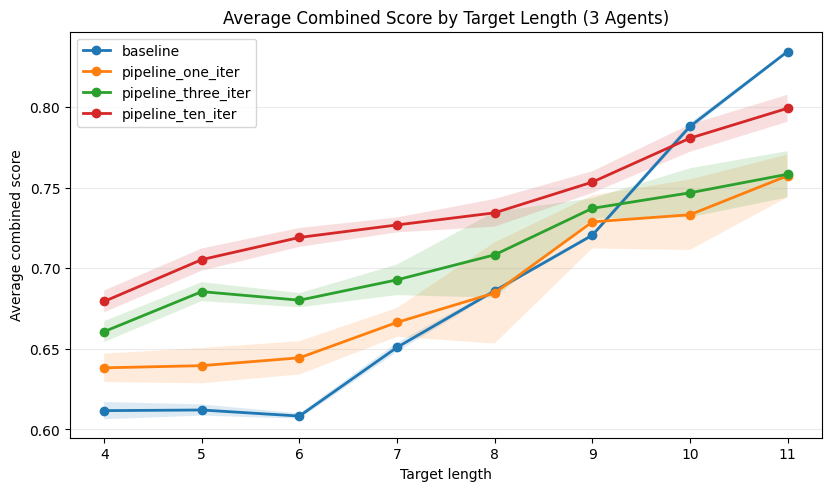

In [30]:
import matplotlib.pyplot as plt
import numpy as np

if "hardness_summary_df" not in globals() or hardness_summary_df.empty:
    print("Run the hard target-length experiment cell first to generate hardness_summary_df.")
else:
    plot_df = hardness_summary_df.copy()
    methods_order = ["baseline", *list(TEST_CONFIG["pipeline_modes"].keys())]

    target_lengths = sorted(plot_df["target_length"].unique(), reverse=True)
    x = np.array(target_lengths, dtype=float)

    fig, ax = plt.subplots(figsize=(8.2, 4.8), constrained_layout=True)

    for method_name in methods_order:
        part = plot_df[plot_df["method"] == method_name].set_index("target_length")
        means = np.array([float(part.loc[t, "avg_score"]) if t in part.index else np.nan for t in target_lengths], dtype=float)
        errs = np.array(
            [
                float(part.loc[t, "std_score"]) if (t in part.index and pd.notna(part.loc[t, "std_score"])) else 0.0
                for t in target_lengths
            ],
            dtype=float,
        )

        ax.plot(x, means, marker="o", linewidth=2.0, label=method_name)
        ax.fill_between(x, means - errs, means + errs, alpha=0.15)

    ax.set_title("Average Combined Score by Target Length (3 Agents)")
    ax.set_xlabel("Target length")
    ax.set_ylabel("Average combined score")
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) for v in x])
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.show()

## Variety Study

Uses results from the previous cell.
Metrics: generated_mean, unique_mean, duplicate_mean, duplicate_rate_mean.

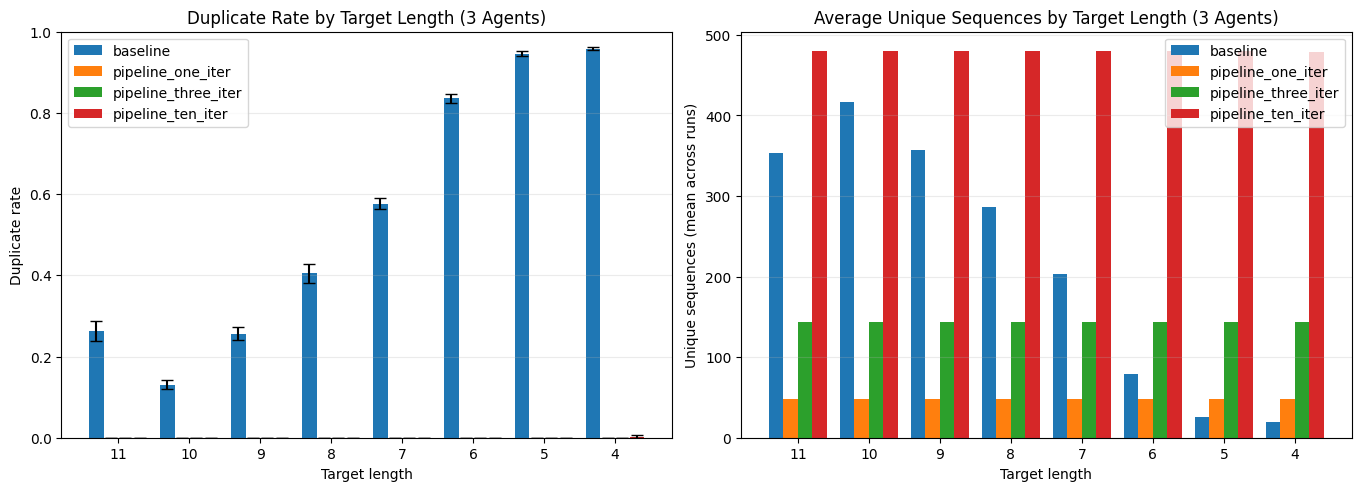

,target_length,method,requested_budget_mean,generated_mean,unique_mean,duplicate_mean,duplicate_rate_mean,duplicate_rate_std,topk_generated_mean,topk_unique_mean,topk_duplicate_mean,topk_duplicate_rate_mean,topk_duplicate_rate_std
0,11,baseline,480.0,480.0,353.6,126.4,0.263333,0.024143,480.0,353.6,126.4,0.263333,0.024143
1,11,pipeline_one_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,2.6,2.6,0.0,0.000000,0.000000
2,11,pipeline_ten_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000
3,11,pipeline_three_iter,144.0,144.0,144.0,0.0,0.000000,0.000000,9.4,9.4,0.0,0.000000,0.000000
4,10,baseline,480.0,480.0,417.2,62.8,0.130833,0.010965,480.0,417.2,62.8,0.130833,0.010965
5,10,pipeline_one_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,2.8,2.8,0.0,0.000000,0.000000
6,10,pipeline_ten_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000
7,10,pipeline_three_iter,144.0,144.0,144.0,0.0,0.000000,0.000000,8.6,8.6,0.0,0.000000,0.000000
8,9,baseline,480.0,480.0,356.8,123.2,0.256667,0.017205,480.0,356.8,123.2,0.256667,0.017205
9,9,pipeline_one_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,3.6,3.6,0.0,0.000000,0.000000


In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "hardness_variety_summary_df" not in globals() or hardness_variety_summary_df.empty:
    print("Run the hard target-length experiment cell first to generate hardness_variety_summary_df.")
else:
    variety_plot_df = hardness_variety_summary_df.copy()
    methods_order = ["baseline", *list(TEST_CONFIG["pipeline_modes"].keys())]

    target_lengths = sorted(variety_plot_df["target_length"].unique(), reverse=True)
    labels = [str(int(v)) for v in target_lengths]
    x = np.arange(len(labels))

    n_methods = max(len(methods_order), 1)
    group_span = 0.82
    width = min(0.35, group_span / n_methods)
    offsets = (np.arange(n_methods) - (n_methods - 1) / 2.0) * width

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), constrained_layout=True)

    for method_name, dx in zip(methods_order, offsets):
        part = variety_plot_df[variety_plot_df["method"] == method_name].set_index("target_length")

        dup_rate = np.array(
            [float(part.loc[t, "duplicate_rate_mean"]) if t in part.index else 0.0 for t in target_lengths],
            dtype=float,
        )
        dup_err = np.array(
            [
                float(part.loc[t, "duplicate_rate_std"])
                if (t in part.index and pd.notna(part.loc[t, "duplicate_rate_std"]))
                else 0.0
                for t in target_lengths
            ],
            dtype=float,
        )
        unique_vals = np.array(
            [float(part.loc[t, "unique_mean"]) if t in part.index else 0.0 for t in target_lengths],
            dtype=float,
        )

        axes[0].bar(
            x + dx,
            dup_rate,
            width,
            yerr=dup_err,
            capsize=4,
            label=method_name,
        )

        axes[1].bar(
            x + dx,
            unique_vals,
            width,
            label=method_name,
        )

    axes[0].set_title("Duplicate Rate by Target Length (3 Agents)")
    axes[0].set_xlabel("Target length")
    axes[0].set_ylabel("Duplicate rate")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].legend()

    axes[1].set_title("Average Unique Sequences by Target Length (3 Agents)")
    axes[1].set_xlabel("Target length")
    axes[1].set_ylabel("Unique sequences (mean across runs)")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend()

    plt.show()

    method_variety_df = (
        variety_plot_df[
            [
                "target_length",
                "method",
                "requested_budget_mean",
                "generated_mean",
                "unique_mean",
                "duplicate_mean",
                "duplicate_rate_mean",
                "duplicate_rate_std",
                "topk_generated_mean",
                "topk_unique_mean",
                "topk_duplicate_mean",
                "topk_duplicate_rate_mean",
                "topk_duplicate_rate_std",
            ]
        ]
        .sort_values(["target_length", "method"], ascending=[False, True])
        .reset_index(drop=True)
    )
    display(method_variety_df)

In [32]:
import gc
gc.collect()
if "torch" in globals() and torch.cuda.is_available():
    torch.cuda.empty_cache()